In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout,LSTM,Input,BatchNormalization,GlobalAveragePooling1D,Activation
import datetime
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from pathlib import Path



In [2]:
def filter_to_shared_range(df,df_bounds,val_cols):
    parts = []
    df_bounds = df_bounds.reset_index()
    for _,row in df_bounds.iterrows():
        activity = row['activity_code']
        t_min = row['min_timestamp']
        t_max = row['max_timestamp']

        mask = (df['activity_code'] == activity) & (df['timestamp'] >= t_min) & (df['timestamp'] <= t_max)

        parts.append(df.loc[mask,['user_id','activity_code','timestamp']+val_cols])
    return pd.concat(parts,ignore_index=True)

    


In [3]:


def filter_and_merge_sensors(accel_path, gyro_path):
    acc_column_names = ['user_id','activity_code','timestamp','ax','ay','az']
    gy_column_names = ['user_id','activity_code','timestamp','gx','gy','gz']
    acc_df = pd.read_csv(accel_path,header=None, names=acc_column_names)
    gy_df =  pd.read_csv(gyro_path,header=None, names=gy_column_names)

    acc_bounds = acc_df.groupby('activity_code')['timestamp'].agg(['min','max'])
    gy_bounds = gy_df.groupby('activity_code')['timestamp'].agg(['min','max'])

    bounds = acc_bounds.join(gy_bounds,lsuffix='_acc',rsuffix='_gy')

    df_bounds = pd.DataFrame(index=bounds.index)
    df_bounds['min_timestamp'] = bounds[['min_acc','min_gy']].max(axis=1)
    df_bounds['max_timestamp'] = bounds[['max_acc','max_gy']].min(axis=1)


    acc_filtered = filter_to_shared_range(acc_df,df_bounds,['ax','ay','az'])
    gy_filtered = filter_to_shared_range(gy_df,df_bounds,['gx','gy','gz'])


    merged_df = pd.merge(
        acc_filtered,
        gy_filtered.drop(columns='user_id'),
        on=[ 'activity_code', 'timestamp'],
    )

    merged_df = merged_df.sort_values(['activity_code','timestamp']).reset_index(drop=True)

    return merged_df

In [4]:
accel_path = Path('phone/accel')
acc_file_names = os.listdir(accel_path)
df = pd.concat((filter_and_merge_sensors(f'phone/accel/{filename}',f'phone/gyro/{filename.replace("accel","gyro")}')  for filename in acc_file_names ))
df = df.sort_values(['user_id','activity_code'],ascending=[True,True])

In [5]:
df = df.astype(str).apply(lambda s: s.str.replace(';','',regex=False).str.strip())

numeric_cols = [
    'user_id',
    'timestamp',
    'ax', 'ay', 'az',
    'gx', 'gy', 'gz'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

In [66]:
df.to_csv("merged_data.csv",index=False)


In [6]:
df.head()

,user_id,activity_code,timestamp,ax,ay,az,gx,gy,gz
0,1600,A,252207918580802,-4.332779,13.361191,-0.718872,-0.853210,0.297226,0.890182
1,1600,A,252207968934806,-0.319443,13.318359,-0.232025,-0.875137,0.015472,0.162231
2,1600,A,252208019288809,1.566452,9.515274,-0.017776,-0.720169,0.388489,-0.284012
3,1600,A,252208069642813,-0.323746,5.262665,0.322342,-0.571640,1.227402,-0.241669
4,1600,A,252208119996817,-1.811676,3.710510,1.373932,-0.380493,1.202835,-0.213135


In [67]:
df.shape

(2909149, 9)

In [3]:
new_df = pd.read_csv("merged_data.csv")

In [4]:
def create_windows(dataframe, window_size=60, step_size=60):
    X_list = []
    y_list = []


    for i in range(0, len(dataframe) - window_size, step_size):
        window = dataframe.iloc[i : i + window_size]

        # Only accept the window if the activity remains identical across the window span
        if window['activity_code'].nunique() == 1 and window['user_id'].nunique() == 1:
            features = window[['ax', 'ay', 'az','gx','gy','gz']].values
            label = window['activity_code'].iloc[0]

            X_list.append(features)
            y_list.append(label)

    return np.array(X_list), np.array(y_list)

In [5]:
X_raw, y_raw = create_windows(new_df)

In [6]:
X_raw.shape

(47684, 60, 6)

found out the correctness of windows

In [33]:
count = 0
for j in range(len(X_raw)):
    user_id = []
    
    for i in range(len(X_raw[j])):
        user_id.append(X_raw[j][i][0])
        
    new_set = set(user_id)
    if len(new_set) != 1:
        print("anomaly found")

anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomaly found
anomal

In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
num_classes = len(np.unique(y_encoded))

# Convert numerical integers to One-Hot binary matrices (e.g., 2 -> [0, 0, 1])
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

# Stratified split to keep activity distributions equal in train/test splits
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_categorical, test_size=0.3, random_state=5, stratify=y_encoded
)

window_count_train,timesteps_train,feature_count_train = X_train.shape
window_count_test,timesteps_test,feature_count_test = X_test.shape

X_train_2D = X_train.reshape(-1,feature_count_train)
X_test_2D = X_test.reshape(-1,feature_count_test)

scaler = StandardScaler()
scaler.fit(X_train_2D)
X_train_scaled = scaler.transform(X_train_2D)
X_test_scaled = scaler.transform(X_test_2D)

X_train_scaled = X_train_scaled.reshape(window_count_train,timesteps_train,feature_count_train)
X_test_scaled = X_test_scaled.reshape(window_count_test,timesteps_test,feature_count_test)

# Extract shape configurations dynamically
time_steps = X_train_scaled.shape[1]  
num_features = X_train_scaled.shape[2]  



In [8]:
y_categorical.shape

(47684, 18)

In [9]:
np.unique(y_encoded, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17]),
 array([2495, 2524, 2632, 2955, 2705, 2732, 2767, 2696, 2624, 2799, 2441,
        2697, 2473, 2401, 2463, 2879, 2709, 2692]))

In [ ]:
print("Compiling 1D-CNN Model...")
model = Sequential([
    # First Convolutional block to extract local spatial-temporal features
    Conv1D(filters=64, kernel_size=3,activation='relu', input_shape=(time_steps, num_features)),
    Conv1D(filters=64, kernel_size=3,activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Second Convolutional block for deeper hierarchical patterns
    Conv1D(filters=128, kernel_size=3,activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Flatten the 3D feature maps to 1D vectors for dense categorization
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output layer using Softmax to get probability distribution over activities
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Compiling 1D-CNN Model...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)              │ (None, 58, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 56, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 26, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1664)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       213,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,714 (991.07 KB)

 Trainable params: 253,714 (991.07 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
X_train_scaled.shape

(33378, 60, 6)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',       # what metric to watch
    patience=7,                # how many epochs to wait for improvement before stopping
    restore_best_weights=True  # roll back to the best epoch's weights, not the last one
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                # multiply LR by this when plateauing
    patience=3,                # wait this many epochs of no improvement before reducing
    min_lr=1e-6
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                # set this high, early stopping will cut it short
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Final validation evaluation
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n==========================================")
print(f"Training Complete!")
print(f"Model Accuracy on Test Set: {test_acc * 100:.2f}%")
print(f"==========================================")

# Display mapping index reference
print("\nClass Mapping Reference:")
for index, class_label in enumerate(label_encoder.classes_):
    print(f"Index {index} corresponds to Activity Code: {class_label}")

Epoch 1/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2132 - loss: 2.2452 - val_accuracy: 0.2962 - val_loss: 1.9590 - learning_rate: 0.0010
Epoch 2/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3098 - loss: 1.9255 - val_accuracy: 0.3727 - val_loss: 1.8071 - learning_rate: 0.0010
Epoch 3/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3689 - loss: 1.7856 - val_accuracy: 0.4108 - val_loss: 1.6779 - learning_rate: 0.0010
Epoch 4/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.4064 - loss: 1.6788 - val_accuracy: 0.4689 - val_loss: 1.5532 - learning_rate: 0.0010
Epoch 5/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.4387 - loss: 1.5773 - val_accuracy: 0.4749 - val_loss: 1.4861 - learning_rate: 0.0010
Epoch 6/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4659 - loss: 1.5006 - val_accuracy: 0.5115 - val_loss: 1.3952 - learning_rate: 0.0010
Epoch 7/100
887/887 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4849 - loss: 1.

448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


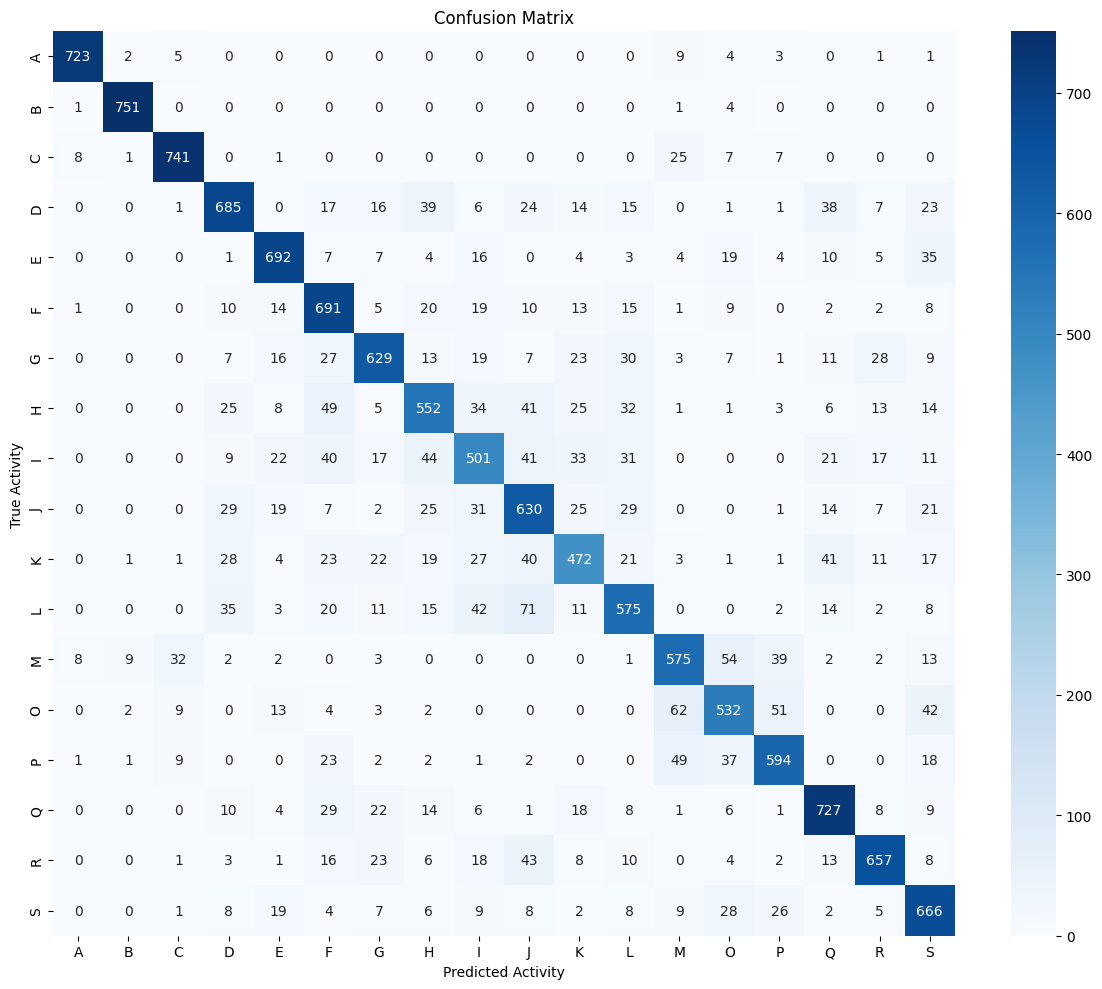

              precision    recall  f1-score   support

           A       0.97      0.97      0.97       748
           B       0.98      0.99      0.99       757
           C       0.93      0.94      0.93       790
           D       0.80      0.77      0.79       887
           E       0.85      0.85      0.85       811
           F       0.72      0.84      0.78       820
           G       0.81      0.76      0.78       830
           H       0.73      0.68      0.70       809
           I       0.69      0.64      0.66       787
           J       0.69      0.75      0.72       840
           K       0.73      0.64      0.68       732
           L       0.74      0.71      0.72       809
           M       0.77      0.77      0.77       742
           O       0.75      0.74      0.74       720
           P       0.81      0.80      0.81       739
           Q       0.81      0.84      0.82       864
           R       0.86      0.81      0.83       813
           S       0.74    

In [27]:


# Get predictions (probabilities) and convert to class indices
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# y_test is one-hot encoded, convert back to class indices too
y_true = np.argmax(y_test, axis=1)

# Build the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Use your actual activity labels instead of 0-17
class_names = label_encoder.classes_

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Per-class precision/recall/f1, often more informative than the raw matrix
print(classification_report(y_true, y_pred, target_names=class_names))